In [3]:
import numpy as np
import pandas as pd
import category_encoders as ce
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, make_scorer,classification_report, roc_auc_score
from ucimlrepo import fetch_ucirepo

Cargamos el conjunto de datos


In [4]:
# fetch dataset 
bank_marketing = fetch_ucirepo(id=222) 
  
# data (as pandas dataframes) 
X = bank_marketing.data.features 
y = bank_marketing.data.targets 
  
# metadata 
print(bank_marketing.metadata) 
  
# variable information 
print(bank_marketing.variables) 

{'uci_id': 222, 'name': 'Bank Marketing', 'repository_url': 'https://archive.ics.uci.edu/dataset/222/bank+marketing', 'data_url': 'https://archive.ics.uci.edu/static/public/222/data.csv', 'abstract': 'The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 45211, 'num_features': 16, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Marital Status', 'Education Level'], 'target_col': ['y'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2014, 'last_updated': 'Fri Aug 18 2023', 'dataset_doi': '10.24432/C5K306', 'creators': ['S. Moro', 'P. Rita', 'P. Cortez'], 'intro_paper': {'ID': 277, 'type': 'NATIVE', 'title': 'A data-driven approach to predict the s

Primero, cargamos los datos. Tenemos más de 500 pacientes y 30 características (radio, textura, perímetro). Siempre utilicen X.info() y X.head() al iniciar un proyecto para entender con qué estamos trabajando

In [5]:
# Binarizar y convertir 'y' en una Serie 1D
y = (y['y'] == 'yes').astype(int)

# Verificar los resultados
print(y.value_counts())

y
0    39922
1     5289
Name: count, dtype: int64


In [6]:
print("Primeras 5 filas del dataset:")
print(X.head())

print("\nColumnas del dataset:")
print(X.columns)

print("\nInformación detallada del dataset:")
X.info()

Primeras 5 filas del dataset:
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married        NaN      no     1506     yes   no   
4   33           NaN   single        NaN      no        1      no   no   

  contact  day_of_week month  duration  campaign  pdays  previous poutcome  
0     NaN            5   may       261         1     -1         0      NaN  
1     NaN            5   may       151         1     -1         0      NaN  
2     NaN            5   may        76         1     -1         0      NaN  
3     NaN            5   may        92         1     -1         0      NaN  
4     NaN            5   may       198         1     -1         0      NaN  

Columnas del dataset:
Index(['age', 'job', 'marital', 'educati

In [7]:
print("Valores únicos en la variable objetivo (y):")
print(np.unique(y, return_counts=True))

print("\nPrimeros 5 elementos de la variable objetivo (y):")
print(y[:5])

Valores únicos en la variable objetivo (y):
(array([0, 1]), array([39922,  5289]))

Primeros 5 elementos de la variable objetivo (y):
0    0
1    0
2    0
3    0
4    0
Name: y, dtype: int64


Empezamos a tratar los valores nulos a ver que sale

In [8]:
# Identificamos las columnas de texto (object) en X
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

# Reemplazamos los NaN por una categoría explícita en las de texto
X[cat_cols] = X[cat_cols].fillna('Unknown')

# Por seguridad, si hubiera algún NaN en las numéricas, usamos la mediana
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
X[num_cols] = X[num_cols].fillna(X[num_cols].median())

C:\Users\ASUS\AppData\Local\Temp\ipykernel_19208\263408085.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object']).columns.tolist()


### 2. Partición de Datos (Estrategia Train / Dev / Test) Primero separamos el Train (80%) del resto (20%), Luego dividimos el 'resto' en Dev (10%) y Test (10%)

In [9]:

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Luego dividimos el 'resto' en Dev (10%) y Test (10%)
X_dev, X_test, y_dev, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Datos de Entrenamiento (Train): {X_train.shape}")
print(f"Datos de Desarrollo (Dev): {X_dev.shape}")
print(f"Datos de Prueba (Test): {X_test.shape}")

Datos de Entrenamiento (Train): (36168, 16)
Datos de Desarrollo (Dev): (4521, 16)
Datos de Prueba (Test): (4522, 16)


### CODIFICACIÓN DE CATEGÓRICAS (Category Encoders)

In [10]:
# Inicializamos el One-Hot Encoder para tus columnas de texto
encoder = ce.OneHotEncoder(cols=cat_cols, use_cat_names=True)

# Ajustamos con el set de entrenamiento y transformamos ambos
X_train_encoded = encoder.fit_transform(X_train)
X_test_encoded = encoder.transform(X_test)
X_dev_encoded = encoder.transform(X_dev)


### ESCALADO DE VARIABLES (lo uso despues para ver los datos sin escalar)

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_encoded)
X_dev_scaled = scaler.transform(X_dev_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

In [12]:
print("Primeras 5 filas del dataset CODIFICADO (Numérico y Binario):")
print(X_train_encoded.head())

print("\nNuevas Columnas del dataset (Expandidas por One-Hot):")
print(X_train_encoded.columns)

print("\nInformación detallada del dataset codificado:")
X_train_encoded.info()

Primeras 5 filas del dataset CODIFICADO (Numérico y Binario):
       age  job_technician  job_student  job_unemployed  job_blue-collar  \
24001   36               1            0               0                0   
43409   24               0            1               0                0   
20669   44               1            0               0                0   
18810   48               0            0               1                0   
23130   38               1            0               0                0   

       job_management  job_services  job_admin.  job_retired  job_Unknown  \
24001               0             0           0            0            0   
43409               0             0           0            0            0   
20669               0             0           0            0            0   
18810               0             0           0            0            0   
23130               0             0           0            0            0   

       ...  month_

### . Construcción del Modelo Base (Baseline) verbose=2 imprimirá el progreso de la convergencia

In [13]:
modelo_base = LogisticRegression(C=1, max_iter=1000, verbose=3)
modelo_base.fit(X_train_scaled, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"verbose verbose: int, default=0For the liblinear and lbfgs solvers set verbose to any positivenumber for verbosity.",3
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None


### EVALUACIÓN DEL MODELO BASELINE

In [14]:
# 4. Evaluación en el conjunto de Desarrollo (Dev)
y_pred_dev = modelo_base.predict(X_dev_scaled)

# Cálculos de Métricas
matriz_conf = confusion_matrix(y_dev, y_pred_dev)
exactitud = accuracy_score(y_dev, y_pred_dev)
precision = precision_score(y_dev, y_pred_dev)
recall = recall_score(y_dev, y_pred_dev)
f1 = f1_score(y_dev, y_pred_dev) # Nuestra métrica de número único

print("\n--- RESULTADOS EN EL CONJUNTO DEV ---")
print("Matriz de Confusión:")
print(matriz_conf)
print(f"Exactitud (Accuracy): {exactitud:.4f}")
print(f"Precisión:            {precision:.4f}")
print(f"Exhaustividad (Recall):{recall:.4f}")
print(f"Puntaje F1 (F1-Score): {f1:.4f}  <-- Métrica de número único")


--- RESULTADOS EN EL CONJUNTO DEV ---
Matriz de Confusión:
[[3883  109]
 [ 341  188]]
Exactitud (Accuracy): 0.9005
Precisión:            0.6330
Exhaustividad (Recall):0.3554
Puntaje F1 (F1-Score): 0.4552  <-- Métrica de número único


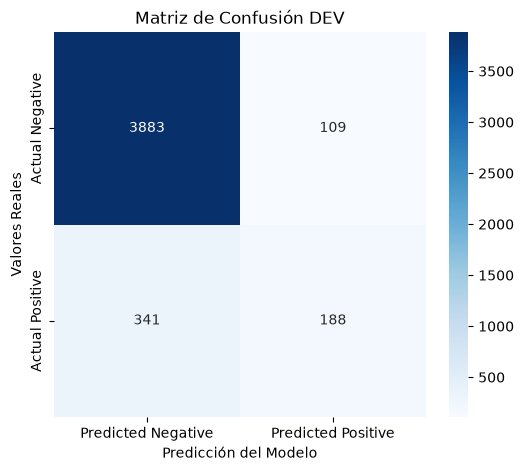

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear un mapa de calor de la matriz de confusión
plt.figure(figsize=(6, 5))
sns.heatmap(matriz_conf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valores Reales')
plt.title('Matriz de Confusión DEV')
plt.show()

In [17]:
# 4. Evaluación en el conjunto de Testeo (Test)
y_pred_test = modelo_base.predict(X_test_scaled)

# Cálculos de Métricas
matriz_conf = confusion_matrix(y_test, y_pred_test)
exactitud = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test)
f1 = f1_score(y_test, y_pred_test) # Nuestra métrica de número único

print("\n--- RESULTADOS EN EL CONJUNTO TEST ---")
print("Matriz de Confusión:")
print(matriz_conf)
print(f"Exactitud (Accuracy): {exactitud:.4f}")
print(f"Precisión:            {precision:.4f}")
print(f"Exhaustividad (Recall):{recall:.4f}")
print(f"Puntaje F1 (F1-Score): {f1:.4f}  <-- Métrica de número único")


--- RESULTADOS EN EL CONJUNTO TEST ---
Matriz de Confusión:
[[3899   94]
 [ 348  181]]
Exactitud (Accuracy): 0.9023
Precisión:            0.6582
Exhaustividad (Recall):0.3422
Puntaje F1 (F1-Score): 0.4502  <-- Métrica de número único


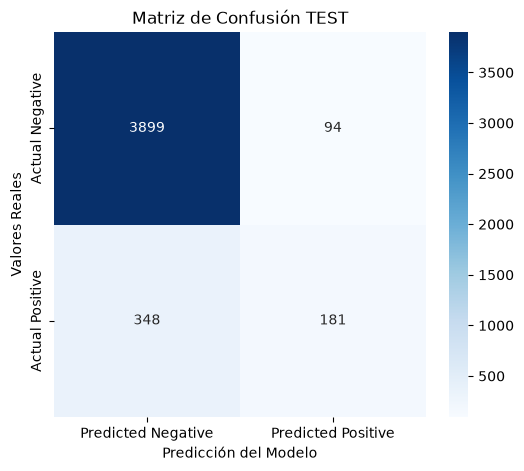

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear un mapa de calor de la matriz de confusión
plt.figure(figsize=(6, 5))
sns.heatmap(matriz_conf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valores Reales')
plt.title('Matriz de Confusión TEST')
plt.show()

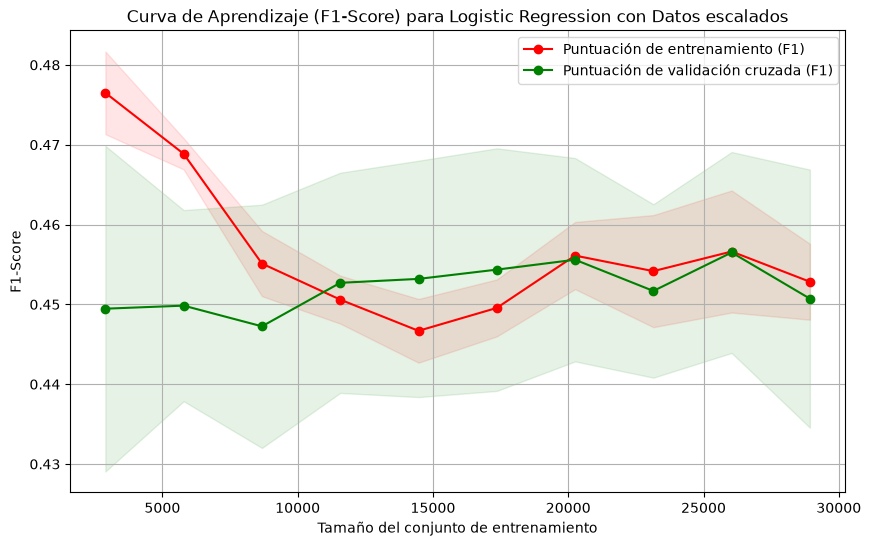

In [19]:
# Definir el scorer para F1-score
f1_scorer = make_scorer(f1_score)

# Generar la curva de aprendizaje con los datos de entrenamiento sin escalar
train_sizes, train_scores, test_scores = learning_curve(
    modelo_base, X_train_scaled, y_train, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), scoring=f1_scorer
)

# Calcular medias y desviaciones estándar
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Plotear la curva de aprendizaje
plt.figure(figsize=(10, 6))
plt.title("Curva de Aprendizaje (F1-Score) para Logistic Regression con Datos escalados")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("F1-Score")
plt.grid()

plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1,
                 color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1,
                 color="g")
plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
         label="Puntuación de entrenamiento (F1)")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
         label="Puntuación de validación cruzada (F1)")

plt.legend(loc="best")
plt.show()

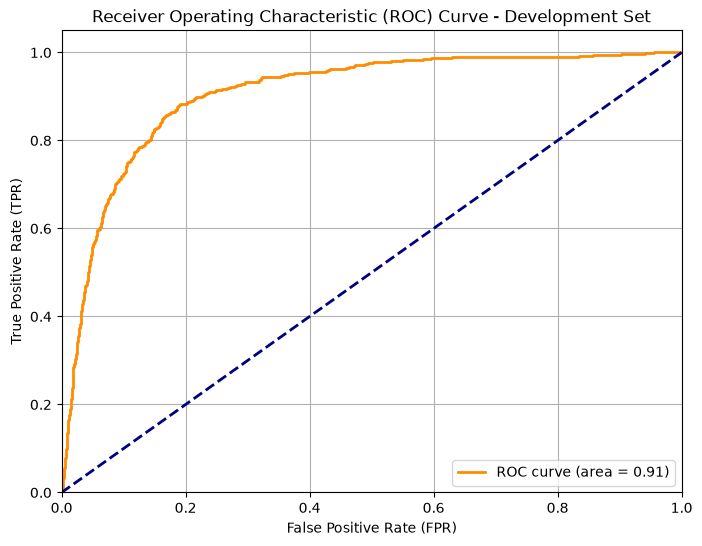

In [20]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Obtener las probabilidades de predicción para la clase positiva en el conjunto de desarrollo
y_pred_proba_dev = modelo_base.predict_proba(X_dev_scaled)[:, 1]

# Calcular la curva ROC
fpr, tpr, thresholds = roc_curve(y_dev, y_pred_proba_dev)
roc_auc = auc(fpr, tpr)

# Plotear la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve - Development Set')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

El punto de partida de la ecuación (Intercepto) es: -2.8464



C:\Users\ASUS\AppData\Local\Temp\ipykernel_19208\2645352252.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


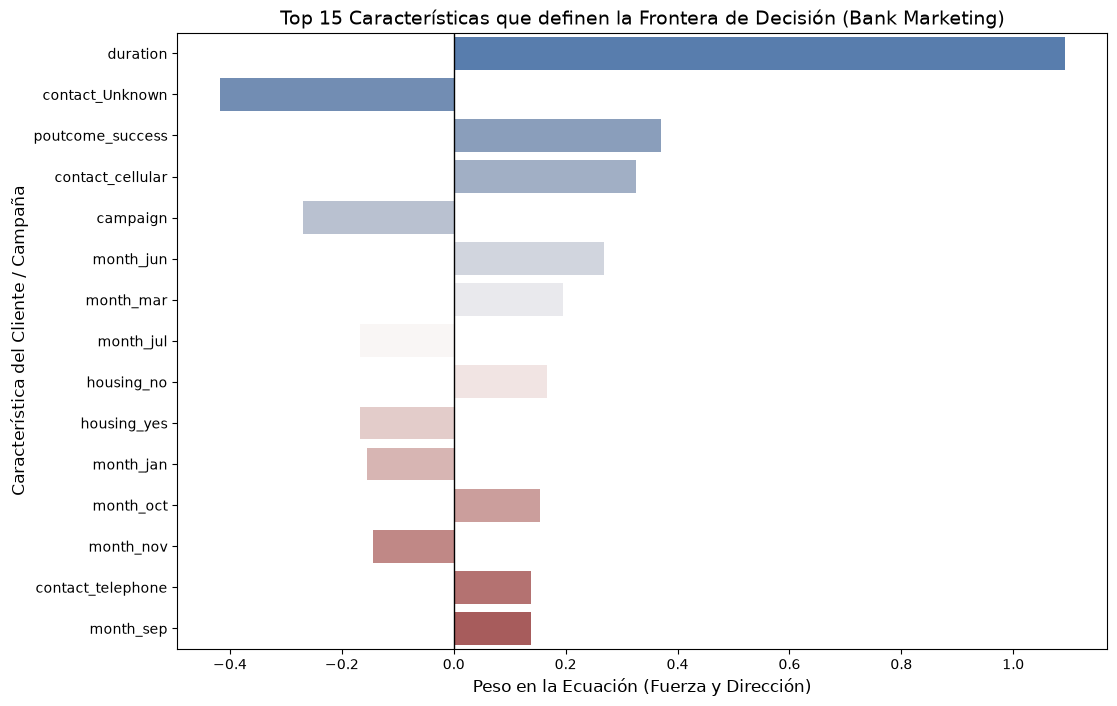

--- TOP 10 VARIABLES CON MÁS IMPACTO ---
      Característica  Peso (Coeficiente)  Impacto Absoluto
43          duration            1.092538          1.092538
29   contact_Unknown           -0.418546          0.418546
50  poutcome_success            0.370722          0.370722
28  contact_cellular            0.325479          0.325479
44          campaign           -0.269882          0.269882
35         month_jun            0.268482          0.268482
38         month_mar            0.194994          0.194994
33         month_jul           -0.166781          0.166781
23        housing_no            0.166693          0.166693
24       housing_yes           -0.166693          0.166693


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Obtenemos el intercepto (el sesgo base del modelo)
sesgo = modelo_base.intercept_[0]
print(f"El punto de partida de la ecuación (Intercepto) es: {sesgo:.4f}\n")

# 2. CORREGIDO: Obtenemos los nombres de las columnas YA CODIFICADAS por One-Hot
nombres_caracteristicas = X_train_encoded.columns

# 3. Extraemos los coeficientes calculados por el modelo
coeficientes = modelo_base.coef_[0]

# 4. Creamos una tabla (DataFrame) para emparejar cada característica con su peso matemático
importancia_variables = pd.DataFrame({
    'Característica': nombres_caracteristicas,
    'Peso (Coeficiente)': coeficientes
})

# 5. Calculamos el "Impacto Absoluto" (fuerza de la variable sin importar su signo)
importancia_variables['Impacto Absoluto'] = importancia_variables['Peso (Coeficiente)'].abs()

# 6. Ordenamos la tabla de mayor a menor impacto para ver las más importantes arriba
importancia_variables = importancia_variables.sort_values(by='Impacto Absoluto', ascending=False)


# --- VISUALIZACIÓN ---
plt.figure(figsize=(12, 8))

# Graficamos el Top 15 de características (ajustado de tu head(30) para que no quede amontonado)
sns.barplot(
    x='Peso (Coeficiente)',
    y='Característica',
    data=importancia_variables.head(15), 
    palette='vlag' # Muestra azul para positivos y rojo para negativos (o viceversa)
)

plt.title('Top 15 Características que definen la Frontera de Decisión (Bank Marketing)', fontsize=14)
plt.xlabel('Peso en la Ecuación (Fuerza y Dirección)', fontsize=12)
plt.ylabel('Característica del Cliente / Campaña', fontsize=12)
plt.axvline(0, color='black', linewidth=1) # Línea en cero para separar impacto positivo de negativo
plt.show()


# --- REPORTE IMPRESO ---
print("--- TOP 10 VARIABLES CON MÁS IMPACTO ---")
print(importancia_variables.head(10)[['Característica', 'Peso (Coeficiente)', 'Impacto Absoluto']])
